## 1. Configurações e Libraries

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt

In [21]:
df = pd.read_csv("data/recalls_stellantis_brasil.csv")
df.head()

,Modelo,Ano Fabricacao,Idade Veiculo,Km,Reclamacoes,Recall
0,Fiat Toro,2023,3.0,32954.0,2.0,Não
1,Fiat Uno,2016,10.0,117794.0,6.0,Não
2,Fiat Uno,2012,14.0,129392.0,4.0,Não
3,Fiat Strada,2019,7.0,46307.0,3.0,Não
4,Fiat Toro,2017,9.0,79988.0,0.0,Não


## 2. Validação e Pré-processamento do Dataset

### 2.1. Tratamenos básicos

In [22]:
print(f"O Dataset possui {df.shape[1]} colunas e {df.shape[0]} linhas.")

O Dataset possui 6 colunas e 1000 linhas.


In [23]:
df.dtypes

Modelo             object
Ano Fabricacao      int64
Idade Veiculo     float64
Km                float64
Reclamacoes       float64
Recall             object
dtype: object

In [24]:
# Normalização de informações tipo string:

df.columns = df.columns.str.strip().str.lower().str.replace(" ","_")

for col in df.columns:
    if df[col].dtype == "O":
        df[col] = df[col].str.strip().str.lower().str.replace(" ", "_", regex=False)

df.head()

,modelo,ano_fabricacao,idade_veiculo,km,reclamacoes,recall
0,fiat_toro,2023,3.0,32954.0,2.0,não
1,fiat_uno,2016,10.0,117794.0,6.0,não
2,fiat_uno,2012,14.0,129392.0,4.0,não
3,fiat_strada,2019,7.0,46307.0,3.0,não
4,fiat_toro,2017,9.0,79988.0,0.0,não


In [25]:
# Proporção da variável target

pd.DataFrame([df["recall"].value_counts(), df["recall"].value_counts(normalize=True)*100]).T

,count,proportion
recall,,
não,702.0,70.2
sim,298.0,29.8


### 2.2. Lidando com NULL e colunas extras

In [26]:
df.isna().sum()

modelo            11
ano_fabricacao     0
idade_veiculo     20
km                46
reclamacoes       16
recall             0
dtype: int64

#### 2.2.1. Ano de Fabricação e Idade do Veículo

In [27]:
# Verificando se ano_fabricacao diz sempre a idade do veiculo:
ano_atual = 2026

df[(df["idade_veiculo"] != (ano_atual - df["ano_fabricacao"])) | (df["ano_fabricacao"].isna())]

,modelo,ano_fabricacao,idade_veiculo,km,reclamacoes,recall
5,fiat_uno,2014,NaN,188249.0,1.0,sim
42,jeep_grand_cherokee,2023,NaN,28771.0,1.0,não
53,fiat_strada,2023,NaN,39313.0,1.0,não
69,fiat_strada,2022,NaN,34900.0,1.0,não
155,fiat_toro,2017,NaN,106948.0,7.0,sim
220,jeep_grand_cherokee,2019,NaN,102720.0,5.0,sim
314,fiat_toro,2017,NaN,130624.0,7.0,não
322,jeep_grand_cherokee,2017,NaN,120487.0,7.0,sim
331,jeep_grand_cherokee,2019,NaN,76277.0,9.0,não
385,ram_2500,2019,NaN,98162.0,2.0,não


In [28]:
df["idade_veiculo"] = df["idade_veiculo"].fillna(ano_atual - df["ano_fabricacao"])
df = df.drop(columns=["ano_fabricacao"])

#### 2.2.2. Reclamações

In [29]:
# Verificando como a coluna de Reclamações se relaciona com o target para decidir como inputar valores

df.groupby(df["reclamacoes"].isna())["recall"].value_counts(normalize=True)

reclamacoes  recall
False        não       0.699187
             sim       0.300813
True         não       0.875000
             sim       0.125000
Name: proportion, dtype: float64

In [30]:
df.groupby(df["reclamacoes"].isna())["recall"].value_counts()

reclamacoes  recall
False        não       688
             sim       296
True         não        14
             sim         2
Name: count, dtype: int64

In [31]:
# Aqui vemos uma taxa de 30% para ~13%, então a ausência nesssa coluna não parece tão aleatória
# O que acho que pode ter acontecido é não ter sido preenchido o valor 0 desses casos. Se eu inputar a média ou mediana no lugar posso acabar atrapalhando o modelo com dados falsos. 
# Vamos anotar uma estratégia + um guardreil, inputar 0 (que faz mais sentido ao invés de só perder a informação em um dataset pequeno) e criar uma coluna se possuia ou não info antes de input.

df["reclamacoes_ausente"] = df["reclamacoes"].isna().astype(int)
df["reclamacoes"] = df["reclamacoes"].fillna(0)

#### 2.2.3. Modelo

In [12]:
df["modelo"].nunique()

9

In [32]:
df.groupby(df["modelo"].isna())["recall"].value_counts(normalize=True)

modelo  recall
False   não       0.702730
        sim       0.297270
True    não       0.636364
        sim       0.363636
Name: proportion, dtype: float64

In [34]:
df.groupby(df["modelo"].isna())["recall"].value_counts()

modelo  recall
False   não       695
        sim       294
True    não         7
        sim         4
Name: count, dtype: int64

In [42]:
# Como temos poucas categorias e parecer não ter uma relação direta entre modelo e recall, vamos fazer de uma forma mais direta e inputar "desconhecido" no modelo

df["modelo"] = df["modelo"].fillna("desconhecido")

#### 2.2.4. KMs

In [39]:
df.groupby(df["km"].isna())["recall"].value_counts(normalize=True)

km     recall
False  não       0.704403
       sim       0.295597
True   não       0.652174
       sim       0.347826
Name: proportion, dtype: float64

In [40]:
df.groupby(df["km"].isna())["recall"].value_counts()

km     recall
False  não       672
       sim       282
True   não        30
       sim        16
Name: count, dtype: int64

In [47]:
df["km"].describe()

count       954.000000
mean      85528.457023
std       49795.326686
min           0.000000
25%       45159.500000
50%       81088.500000
75%      120265.250000
max      244654.000000
Name: km, dtype: float64

<Axes: >

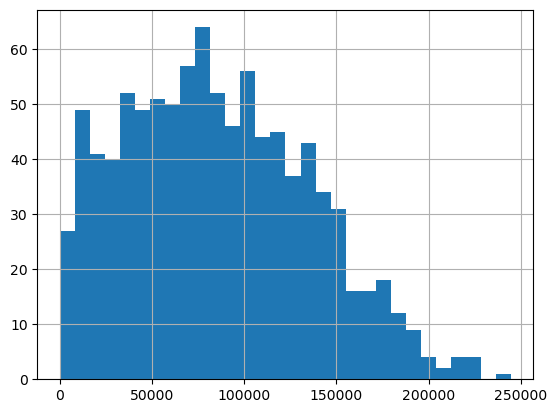

In [48]:
df["km"].hist(bins=30)

In [49]:
# Como temos alguns casos puxando um cauda à direita, como valores relativamente altos de KMs rodados, aqui foi optar por inputar a mediana.
# Mesmo a média e mediana estando bem próximas, acho que por coerência vou manter Mediana como valor de input

df["km"] = df["km"].fillna(df["km"].median())

#### 2.2.5. Validação Final

In [50]:
df.isna().sum()

modelo                 0
idade_veiculo          0
km                     0
reclamacoes            0
recall                 0
reclamacoes_ausente    0
dtype: int64

## 3. Exploração dos Dados

### 3.1. Variáveis Numéricas

In [52]:
# Pensando em incluir uma variavel que acho interessante, km/idade. Vamos realizar alguns testes
# É importante verificar os casos de idade = 0 para não dar erro na divisão

df["idade_veiculo"].value_counts().sort_index()

idade_veiculo
0.0      23
1.0      48
2.0      73
3.0      74
4.0      62
5.0      64
6.0      84
7.0      86
8.0      88
9.0      95
10.0    104
11.0     61
12.0     53
13.0     37
14.0     26
15.0     22
Name: count, dtype: int64

In [53]:
# Para essa situação, vamos só substituir por 1 para não quebrar o código

df["km_por_ano"] = df["km"] / df["idade_veiculo"].replace(0, 1)

In [55]:
# Olhando para os valores, percebemos uma diferença relativametne interessantes por variável entre com recall e sem recall
# O problema é a variável nova, aparentemente os dois grupos se comportam de maneira muito parecida. Olhando os valores
# Media: 11.9k x 12.3k (~3%)
# Mediana: 11.7k x 12.0k (~3%)

df.groupby("recall")[["km", "idade_veiculo", "reclamacoes", "km_por_ano"]].agg(["mean", "median"]).round(2)

km           idade_veiculo        reclamacoes         \
             mean    median          mean median        mean median   
recall                                                                
não      75320.26   71297.0          6.39    6.0        4.69    4.0   
sim     108890.60  108305.0          9.02    9.0        7.39    7.0   

       km_por_ano            
             mean    median  
recall                       
não      11903.82  11667.44  
sim      12255.62  12043.70

In [56]:
# Vamos fazer uma analise bi-variada simples de correlação sobre a coluna km_por_ano
# Olhando a correção entre recall e km_por_ano, 0.03 -> muito fraca, mais um ponto para o descarte

# Outro problema que surgiu aqui é a questão de idade_veiculo e km. Elas tem um valor bem alto de correlação entre si. Isso talvez entre como um caso de multicolinearidade. 
# Pensando nas variáveis diremtante, elas dizem coisas muito parecidas, pois carros mais velhos tendem a ter mais KMs rodados mesmo.
# Isso vai ser importante na hora de rodar os modelos.
# Dados que correlação entre elas e o target ser muito próxima (0.3158 e 0.3163), talvez valha utilizar apenas 1, a decidir.

df_corr = df.copy()
df_corr["recall_bin"] = (df_corr["recall"] == "sim").astype(int)

df_corr[["km", "idade_veiculo", "reclamacoes", "km_por_ano", "recall_bin"]].corr()

,km,idade_veiculo,reclamacoes,km_por_ano,recall_bin
km,1.000000,0.889323,0.688539,0.260550,0.315804
idade_veiculo,0.889323,1.000000,0.723382,-0.044924,0.316343
reclamacoes,0.688539,0.723382,1.000000,0.023151,0.337748
km_por_ano,0.260550,-0.044924,0.023151,1.000000,0.030743
recall_bin,0.315804,0.316343,0.337748,0.030743,1.000000


### 3.2. Variáveis Categóricas

In [ ]:
# Olhando para o Modelo agora, para ver a relação dela com a target
# Como  é categórica, correlação numérica (tipo Pearson) não vai servir
# O jeito certo de comparar é taxa de recall por grupo, junto com o desgaste médio de cada um (idade/km/reclamações), pra saber se a diferença é um efeito próprio

# Tem bastante bastante casos por categoria (menos em desconhecido, mas isso foi input de Null)
# A diferença entre o maior e menor é bem interessante para uma olhada com mais detalhe (11.5% x 46.2%)

# É legal ver as infos numéricas aqui para ver se tem um padrão ou não, tipo mais antigo mais recall, porém ram_2500 e jeep_grand_cherokee parecem não ser
# necessariamente verdade, porque eles vão no contrafluxo isso (alto recall x baixos valores das outras variáveis)

resumo_modelo = df.groupby("modelo")["recall"].agg(
    total_casos="count",
    taxa_recall=lambda x: (x == "sim").mean(),
).sort_values(by="taxa_recall", ascending=False)

resumo_modelo = resumo_modelo.join(
    df.groupby("modelo")[["idade_veiculo", "km", "reclamacoes"]].mean().round(1)
)

resumo_modelo

,total_casos,taxa_recall,idade_veiculo,km,reclamacoes
modelo,,,,,
ram_2500,80,0.462500,7.4,87724.2,6.7
fiat_grand_siena,80,0.412500,10.7,127034.6,7.9
fiat_uno,88,0.409091,10.8,122310.3,8.0
jeep_grand_cherokee,107,0.373832,6.6,83509.7,5.4
desconhecido,11,0.363636,7.5,92187.5,5.6
fiat_palio,80,0.362500,12.2,143093.1,8.9
jeep_renegade,138,0.362319,6.4,77562.4,5.0
jeep_compass,149,0.214765,5.4,64439.4,4.2
fiat_strada,128,0.164062,5.0,57868.1,3.5


In [ ]:
# Pra cravar o que estávemos discutindo antes, rodamos um teste de qui-quadrado entre modelo e recall pois são variáveis categóricas
# Com o resultado de Chi² = 66.18 e p-valor = 0.0000 -> podemos dizer que não são independentes, e é estatistiticamente significativo a relação

from scipy.stats import chi2_contingency

tabela = pd.crosstab(df["modelo"], df["recall"])
chi2, p, dof, expected = chi2_contingency(tabela)
print(f"Chi2: {chi2:.2f}, p-valor: {p:.5f}")

Chi2: 66.18, p-valor: 0.00000


In [ ]:
# Olhando mais a fundo os modelos de ram_500 e grand_cherokee
# É interessantes olhar que 2017 tem um valor bem alto, mas como temos muitos recortes, com pouquissimos carros por recorte não da pra cravar nada ainda

ano_atual = 2026
df["ano_fabricacao_calc"] = ano_atual - df["idade_veiculo"]

subset_ram = df[df["modelo"] == "ram_2500"]

taxa_ram = subset_ram.groupby("ano_fabricacao_calc")["recall"].apply(lambda x: (x == "sim").mean())
contagem_ram = subset_ram.groupby("ano_fabricacao_calc").size()

pd.DataFrame({"taxa_recall": taxa_ram, "total_casos": contagem_ram})

,taxa_recall,total_casos
ano_fabricacao_calc,,
2014.0,0.555556,9
2015.0,0.500000,6
2016.0,0.500000,10
2017.0,0.909091,11
2018.0,0.500000,8
2019.0,0.200000,10
2020.0,0.000000,3
2021.0,0.625000,8
2022.0,0.000000,3


In [64]:
subset_gc = df[df["modelo"] == "jeep_grand_cherokee"]

taxa_gc = subset_gc.groupby("ano_fabricacao_calc")["recall"].apply(lambda x: (x == "sim").mean())
contagem_gc = subset_gc.groupby("ano_fabricacao_calc").size()

pd.DataFrame({"taxa_recall": taxa_gc, "total_casos": contagem_gc})

,taxa_recall,total_casos
ano_fabricacao_calc,,
2014.0,0.555556,9
2015.0,0.500000,6
2016.0,0.400000,10
2017.0,0.777778,9
2018.0,0.363636,11
2019.0,0.500000,8
2020.0,0.312500,16
2021.0,0.000000,4
2022.0,0.300000,10


In [ ]:
# Isolando apenas os modelos ram_2500 e grand_cherokee, a taxa de recall deles fabricados em 2017 é mais alta que o restante dos anos
# Isso pode indicar algum tipo de problema específico para esses modelos de 2017.
# Como a amostra ainda é pequena dado o recorte, não consigo cravar mas parece um padrão interessante de analisar.

df.groupby("ano_fabricacao_calc")["recall"].agg(
    total_casos="count",
    taxa_recall=lambda x: (x == "sim").mean(),
).sort_index()

,total_casos,taxa_recall
ano_fabricacao_calc,,
2011.0,22,0.363636
2012.0,26,0.538462
2013.0,37,0.459459
2014.0,53,0.433962
2015.0,61,0.426230
2016.0,104,0.509615
2017.0,95,0.536842
2018.0,88,0.340909
2019.0,86,0.220930


## 4. Escolha de Modelos

### 4.1. Escolha das Features e Separação de Datasets

In [72]:
from sklearn.model_selection import train_test_split

In [ ]:
# Não utilizei todas as features analisadas anteriormente. Uma vez que algumas não faziam sentido ficou assim:
# - modelo: utilizada pois apresenta uma relação bem interessantes com o target
# - idade_veiculo: utilizada pois também traz informações importantes de uso do veículo
# - km: removida pois apresenta uma relação muito forte com idade_veiculo, acaba trazendo o memso nível de informação -> vale testar com e sem
# - reclamacoes: utilizada pois aparentemente tem uma relação com recall
# - reclamacoes_ausente: utilizada pois é um sinal para os modelos sobre o input da info reclamações, para minimizar viés trazido pelo input
# - km_por_ano: removida pois apresentou um sinal muito fraco com recall
# - ano_fabricacao_calc: utilizada apenas na EDA
# - recall: target que queremos prever

categorical = ["modelo"]
numerical = ["idade_veiculo", "reclamacoes", "reclamacoes_ausente"]
target = "recall"

In [96]:
X = df[categorical + numerical].copy()
y = df[target].map({"não": 0, "sim": 1})

In [99]:
# Vamos utilizar a estratégia Treino / Validação / Teste -> então teremos 3 datasets
# O ideal é 60% / 20 % / 20% -> como vamos usar o train_test_split, vamos colocar 25% no valor pq ele pega 25% dos 80% do primeiro split, resultando nos 20%

test_size = 0.2
val_size = 0.25
random_state = 42

In [120]:
X_full, X_test, y_full, y_test = train_test_split(
                                                X, 
                                                y, 
                                                test_size=test_size, 
                                                random_state=random_state,
                                                stratify=y
                                                )

In [121]:
X_train, X_val, y_train, y_val = train_test_split(
                                                X_full, 
                                                y_full, 
                                                test_size=val_size, 
                                                random_state=random_state,
                                                stratify=y_full
                                                )

In [122]:
# Validando a estratificação da base nos 3 datasets

(pd.DataFrame({
    "Original": y.value_counts(normalize=True),
    "Treino": y_train.value_counts(normalize=True),
    "Validação": y_val.value_counts(normalize=True),
    "Teste": y_test.value_counts(normalize=True)
})*100).round(2)

,Original,Treino,Validação,Teste
recall,,,,
0,70.2,70.17,70.5,70.0
1,29.8,29.83,29.5,30.0


In [123]:
print(f"O DF de Treino possui {X_train.shape[1]} colunas e {X_train.shape[0]} linhas.")
print(f"O DF de Validação possui {X_val.shape[1]} colunas e {X_val.shape[0]} linhas.")
print(f"O DF de Teste possui {X_test.shape[1]} colunas e {X_test.shape[0]} linhas.")

O DF de Treino possui 4 colunas e 600 linhas.
O DF de Validação possui 4 colunas e 200 linhas.
O DF de Teste possui 4 colunas e 200 linhas.


### 4.2. Treinar um baseline

In [ ]:
# !pip install feature_engine

In [136]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [137]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", MinMaxScaler(), numerical),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical) 
    ]
)

In [138]:
model = linear_model.LogisticRegression(
                                    penalty = None,
                                    random_state = random_state,
                                    max_iter = 1000000)

In [139]:
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

In [140]:
features = categorical + numerical
model_pipeline.fit(X_train[features], y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [141]:
y_train_predict = model_pipeline.predict(X_train[features])
y_train_proba = model_pipeline.predict_proba(X_train[features])[:, 1]

acc_train = metrics.accuracy_score(y_train, y_train_predict)
auc_train = metrics.roc_auc_score(y_train, y_train_proba)

print("Acurácia [Treino] =", round(acc_train, 4))
print("AUC [Treino] =", round(auc_train, 4))

Acurácia [Treino] = 0.7383
AUC [Treino] = 0.771
